# Market Regime Detection — K-Means Clustering

**Author:** Quantitative Research Portfolio  
**Model:** K-Means Clustering  
**Assets:** META · TSLA · NIFTY 50 · NIFTY Bank  

---

### Objective

Financial markets cycle through distinct behavioural states — periods of calm trending growth, choppy consolidation, and acute stress. This notebook detects these **latent market regimes** using K-Means clustering applied to a multi-dimensional feature set built from 10 years of daily equity data.

### What is K-Means?

K-Means groups each trading day into one of *k* clusters by minimising within-cluster variance across the feature space. Each day is classified independently — the model has **no memory of what came before**.

| Strengths | Limitations |
|---|---|
| Fast and interpretable | Treats every day as independent |
| No distributional assumptions | Transition matrix is post-hoc, not modelled |
| Works well for static profiling | Hard assignments — no uncertainty quantification |

### Features Engineered

| Feature | Formula | What it captures |
|---|---|---|
| `Return` | ln(Pₜ / Pₜ₋₁) | Daily direction and magnitude |
| `GARCH_vol` | GARCH(1,1) conditional σ | Forward-looking volatility |
| `Volatility` | 20-day rolling σ | Realised short-term volatility |
| `Momentum` | Pₜ / Pₜ₋₂₀ − 1 | 1-month trend (scale-independent) |
| `Drawdown` | (Pₜ − max P) / max P | Distance from all-time high |

---
## 0 · Install & Import

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import yfinance as yf
from arch import arch_model
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#plt.style.use('dark_background')
sns.set_style('darkgrid')
sns.set_context('talk')

COLOR_MAP  = {'Bull': '#2ca02c', 'Correction': '#1f77b4', 'Crash': '#d62728'}
REGIME_ORDER = ['Bull', 'Correction', 'Crash']

print('✓ All imports successful')

✓ All imports successful


---
## 1 · Configuration

Change `SYMBOL` here to run the full analysis on a different asset.

In [2]:
# ── CONFIG — change SYMBOL to switch asset ───────────────────────────────────
SYMBOL     = 'META'       # Options: 'META', 'TSLA', '^NSEI', '^NSEBANK'
PERIOD     = '10y'
N_CLUSTERS = 3
SEED       = 42

NAMES = {
    'META': 'Meta Platforms', 'TSLA': 'Tesla',
    '^NSEI': 'NIFTY 50',      '^NSEBANK': 'NIFTY Bank'
}
NAME = NAMES.get(SYMBOL, SYMBOL)

print(f'Asset      : {NAME} ({SYMBOL})')
print(f'Period     : {PERIOD}')
print(f'N clusters : {N_CLUSTERS}')

Asset      : Meta Platforms (META)
Period     : 10y
N clusters : 3


---
## 2 · Data Download

In [3]:
raw = yf.download(SYMBOL, period=PERIOD, auto_adjust=True, progress=False)

# Handle MultiIndex safely
if isinstance(raw.columns, pd.MultiIndex):
    col    = 'Close' if 'Close' in raw.columns.get_level_values(0) else raw.columns.get_level_values(0)[0]
    prices = raw.xs(col, level=0, axis=1).squeeze().dropna()
else:
    prices = raw['Close'].dropna() if 'Close' in raw.columns else raw.iloc[:, 0].dropna()

data = prices.to_frame(name='Close')

print(f'Rows       : {len(data):,}')
print(f'Date range : {data.index[0].date()} → {data.index[-1].date()}')

Rows       : 2,513
Date range : 2016-04-11 → 2026-04-08


---
## 3 · Feature Engineering

In [4]:
# Log returns
data['Return'] = np.log(data['Close'] / data['Close'].shift(1))

# GARCH(1,1) conditional volatility
returns_pct = data['Return'].dropna() * 100
garch_fit   = arch_model(returns_pct, vol='Garch', p=1, q=1).fit(disp='off')
data.loc[returns_pct.index, 'GARCH_vol'] = garch_fit.conditional_volatility / 100

# 20-day rolling realised volatility
data['Volatility'] = data['Return'].rolling(20).std()

# Percentage momentum — scale-independent
data['Momentum'] = data['Close'] / data['Close'].shift(20) - 1

# Drawdown from rolling all-time high
data['Rolling_Max'] = data['Close'].cummax()
data['Drawdown']    = (data['Close'] - data['Rolling_Max']) / data['Rolling_Max']

data = data.dropna().copy()

print(f'Features engineered. Final shape: {data.shape}')
data[['Return', 'GARCH_vol', 'Volatility', 'Momentum', 'Drawdown']].describe().round(5)

Features engineered. Final shape: (2493, 7)


,Return,GARCH_vol,Volatility,Momentum,Drawdown
count,2493.00000,2493.00000,2493.00000,2493.00000,2493.00000
mean,0.00066,0.02440,0.02144,0.01847,-0.15886
std,0.02451,0.01099,0.01193,0.09972,0.17681
min,-0.30639,0.01502,0.00440,-0.37161,-0.76736
25%,-0.00959,0.01844,0.01392,-0.03385,-0.21056
50%,0.00091,0.02120,0.01833,0.02293,-0.10327
75%,0.01225,0.02623,0.02594,0.07220,-0.02638
max,0.20931,0.15197,0.07718,0.48206,0.00000


---
## 4 · Price History

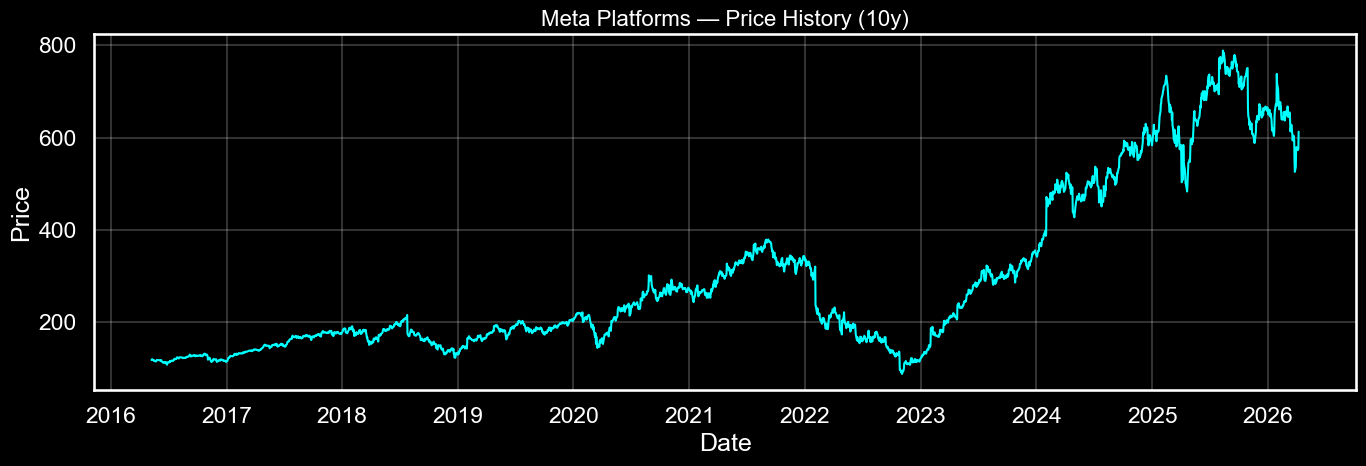

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data.index, data['Close'], color='#00FFFF', linewidth=1.5)
ax.set_title(f'{NAME} — Price History ({PERIOD})', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(alpha=0.2)
plt.style.use('dark_background')
plt.tight_layout()
plt.show()

---
## 5 · Volatility Clustering — Motivation for Regime Detection

Volatility clustering — high-vol periods persisting together — is the empirical justification for regime modelling.

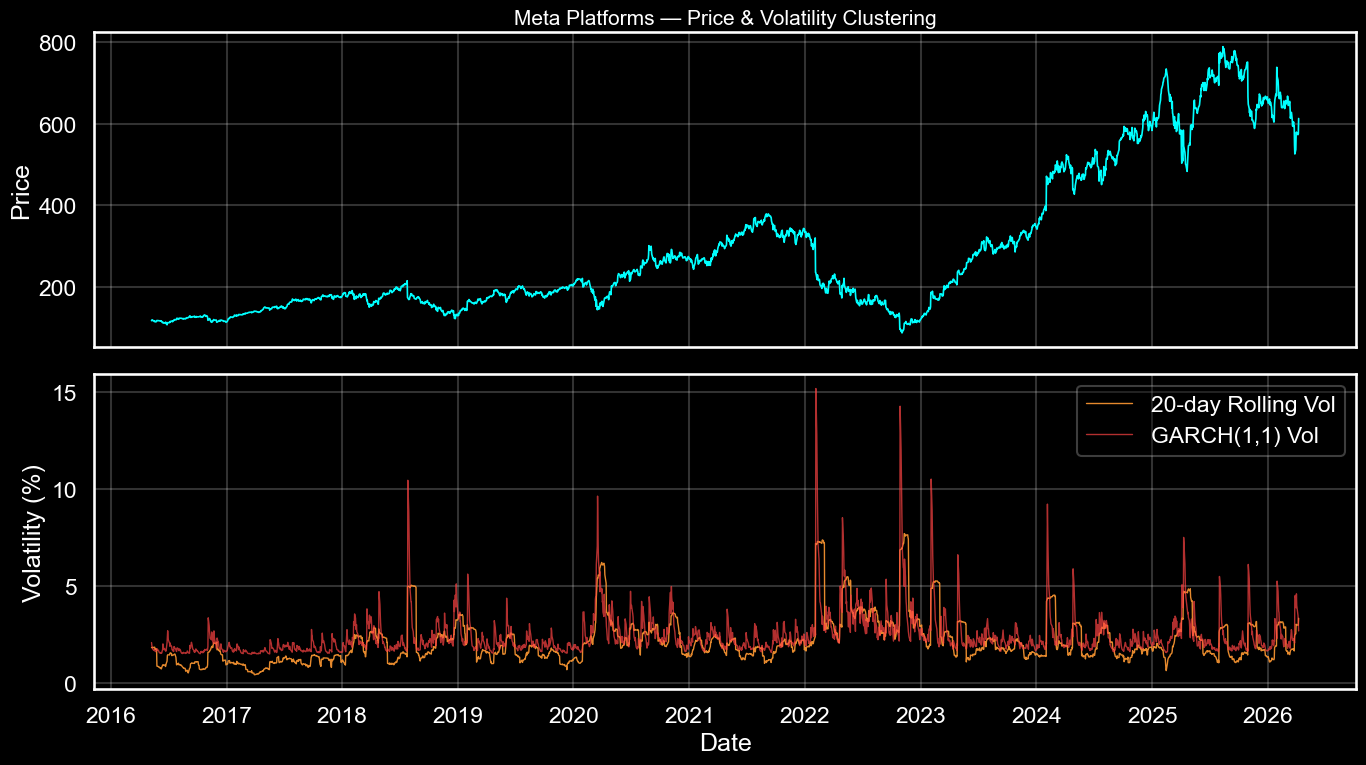

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(data.index, data['Close'], color='#00FFFF', linewidth=1.2)
axes[0].set_ylabel('Price')
axes[0].set_title(f'{NAME} — Price & Volatility Clustering', fontsize=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].grid(alpha=0.2)

axes[1].plot(data.index, data['Volatility'] * 100,
             color='#FF9933', linewidth=1, alpha=0.9, label='20-day Rolling Vol')
axes[1].plot(data.index, data['GARCH_vol'] * 100,
             color='#FF4444', linewidth=1, alpha=0.7, label='GARCH(1,1) Vol')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_xlabel('Date')
axes[1].legend(framealpha=0.3)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.style.use('dark_background')
plt.show()

---
## 6 · Model Selection — How Many Clusters?

**Elbow Method:** Looks for the point where adding another cluster gives diminishing returns in reducing inertia.  
**Silhouette Score:** Measures how well each point fits its own cluster vs neighbours. Higher is better.

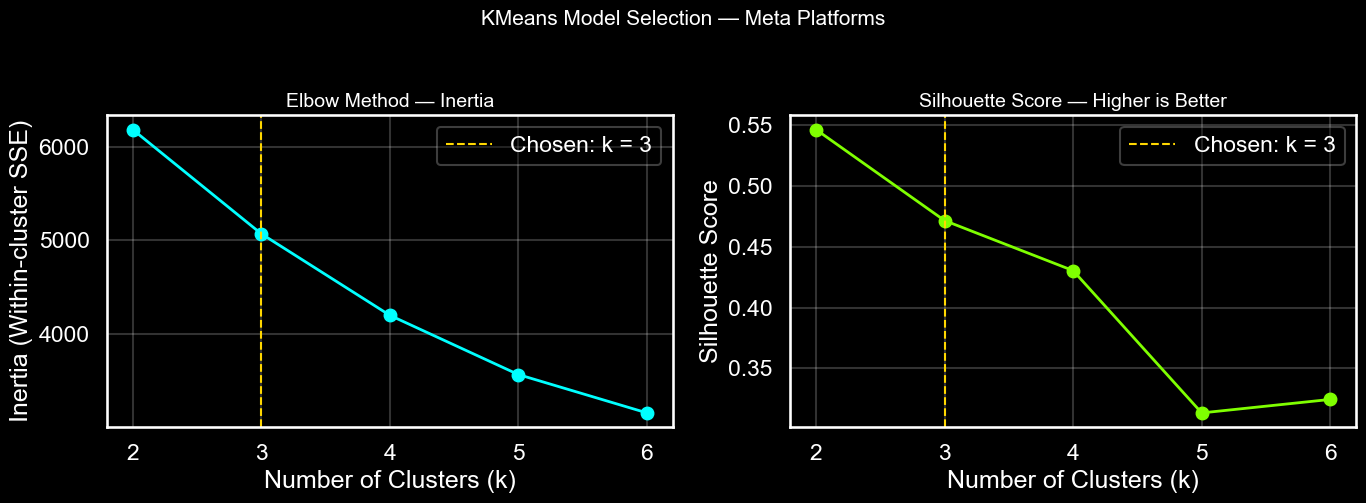

Silhouette scores: {2: 0.547, 3: 0.472, 4: 0.43, 5: 0.313, 6: 0.324}

Note: k=2 may peak on silhouette (mathematically cleanest), but k=3 is chosen
for financial interpretability: Bull / Correction / Crash is actionable.


In [7]:
FEATURE_COLS = ['Volatility', 'Momentum', 'Drawdown', 'GARCH_vol']

scaler = StandardScaler()
X      = scaler.fit_transform(data[FEATURE_COLS])

K           = range(2, 7)
inertias    = []
silhouettes = []

for k in K:
    km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, lbl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K, inertias, 'o-', color='#00FFFF', linewidth=2, markersize=9)
ax1.axvline(x=N_CLUSTERS, color='#FFD700', linestyle='--',
            linewidth=1.5, label=f'Chosen: k = {N_CLUSTERS}')
ax1.set_title('Elbow Method — Inertia', fontsize=14)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster SSE)')
ax1.legend(framealpha=0.3)
ax1.grid(alpha=0.2)

ax2.plot(K, silhouettes, 'o-', color='#7FFF00', linewidth=2, markersize=9)
ax2.axvline(x=N_CLUSTERS, color='#FFD700', linestyle='--',
            linewidth=1.5, label=f'Chosen: k = {N_CLUSTERS}')
ax2.set_title('Silhouette Score — Higher is Better', fontsize=14)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend(framealpha=0.3)
ax2.grid(alpha=0.2)

plt.suptitle(f'KMeans Model Selection — {NAME}', fontsize=15, y=1.02)
plt.tight_layout()
plt.style.use('dark_background')
plt.show()

print(f'Silhouette scores: {dict(zip(K, [round(s, 3) for s in silhouettes]))}')
print()
print('Note: k=2 may peak on silhouette (mathematically cleanest), but k=3 is chosen')
print('for financial interpretability: Bull / Correction / Crash is actionable.')

---
## 7 · Fit K-Means & Auto-Label Regimes

K-Means assigns arbitrary numeric IDs (0, 1, 2) with no inherent meaning. We assign labels based on empirical cluster statistics — conflict-free and reproducible regardless of random initialisation:

1. **Bull** → cluster with highest mean return
2. **Crash** → cluster with highest mean volatility (excluding Bull)
3. **Correction** → remaining cluster

In [8]:
# Fit
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
data['Regime'] = kmeans.fit_predict(X).astype(int)

# Auto-label — conflict-free sequential assignment
stats = data.groupby('Regime').agg(
    mean_return=('Return',    'mean'),
    mean_vol   =('Volatility','mean')
)
stats.index   = stats.index.astype(int)
data['Regime'] = data['Regime'].astype(int)

bull       = int(stats['mean_return'].idxmax())
remaining  = stats.drop(index=bull)
crash      = int(remaining['mean_vol'].idxmax())
correction = int([r for r in stats.index if r not in [bull, crash]][0])

regime_labels        = {bull: 'Bull', crash: 'Crash', correction: 'Correction'}
data['Regime_Label'] = data['Regime'].map(regime_labels)

# Sanity check
if stats.loc[bull, 'mean_return'] < 0:
    print('⚠️  Warning: Bull regime has negative returns — inspect outputs carefully')

print('Regime mapping:', regime_labels)
print()
print('Cluster statistics:')
print(stats.round(6))

Regime mapping: {0: 'Bull', 2: 'Crash', 1: 'Correction'}

Cluster statistics:
        mean_return  mean_vol
Regime                       
0          0.001311  0.017040
1          0.000376  0.031850
2         -0.012057  0.060868


---
## 8 · Regime Statistics Table

In [9]:
z = 2.33

# VaR — grouped directly on label to avoid type-mismatch bugs
var_by_regime = data.groupby('Regime_Label').apply(
    lambda x: -(x['Return'].mean() + z * x['Return'].std())
).rename('VaR_99').reset_index()
var_by_regime.columns = ['Regime_Label', 'VaR_99']

# Average duration
regime_run   = (data['Regime_Label'] != data['Regime_Label'].shift()).cumsum()
avg_duration = (data.groupby(['Regime_Label', regime_run])
                    .size()
                    .groupby(level=0).mean()
                    .rename('Avg_Duration').reset_index())
avg_duration.columns = ['Regime_Label', 'Avg_Duration']

# Core stats
summary = data.groupby('Regime_Label').agg(
    Return    =('Return',    'mean'),
    Volatility=('Volatility','mean'),
    GARCH_Vol =('GARCH_vol', 'mean'),
    Drawdown  =('Drawdown',  'mean'),
).reset_index()

summary = (summary
    .merge(var_by_regime,  on='Regime_Label')
    .merge(avg_duration,   on='Regime_Label')
    .sort_values('Return', ascending=False)
    .reset_index(drop=True))

summary.style \
    .format({
        'Return'     : '{:.2%}',
        'Volatility' : '{:.2%}',
        'GARCH_Vol'  : '{:.2%}',
        'Drawdown'   : '{:.2%}',
        'VaR_99'     : '{:.2%}',
        'Avg_Duration': '{:.1f}',
    }) \
    .set_caption(f'📊 {NAME} — KMeans Regime Summary') \
    .background_gradient(cmap='RdYlGn', subset=['Return']) \
    .background_gradient(cmap='Reds',   subset=['Volatility', 'GARCH_Vol']) \
    .background_gradient(cmap='Purples',subset=['VaR_99']) \
    .background_gradient(cmap='Greys',  subset=['Avg_Duration']) \
    .set_properties(**{'text-align': 'center', 'border': '1px solid #444', 'font-size': '12pt'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#111'), ('color', 'white'),
            ('font-weight', 'bold'), ('text-align', 'center'),
            ('border', '1px solid #444')]},
        {'selector': 'td', 'props': [('border', '1px solid #444')]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'), ('font-size', '15px'),
            ('font-weight', 'bold'), ('color', 'white')]},
    ])

,Regime_Label,Return,Volatility,GARCH_Vol,Drawdown,VaR_99,Avg_Duration
0,Bull,0.13%,1.70%,2.11%,-8.26%,-4.41%,66.4
1,Correction,0.04%,3.19%,3.10%,-41.28%,-7.86%,12.3
2,Crash,-1.21%,6.09%,6.11%,-44.30%,-12.37%,6.8


---
## 9 · Regime-Colored Price Chart

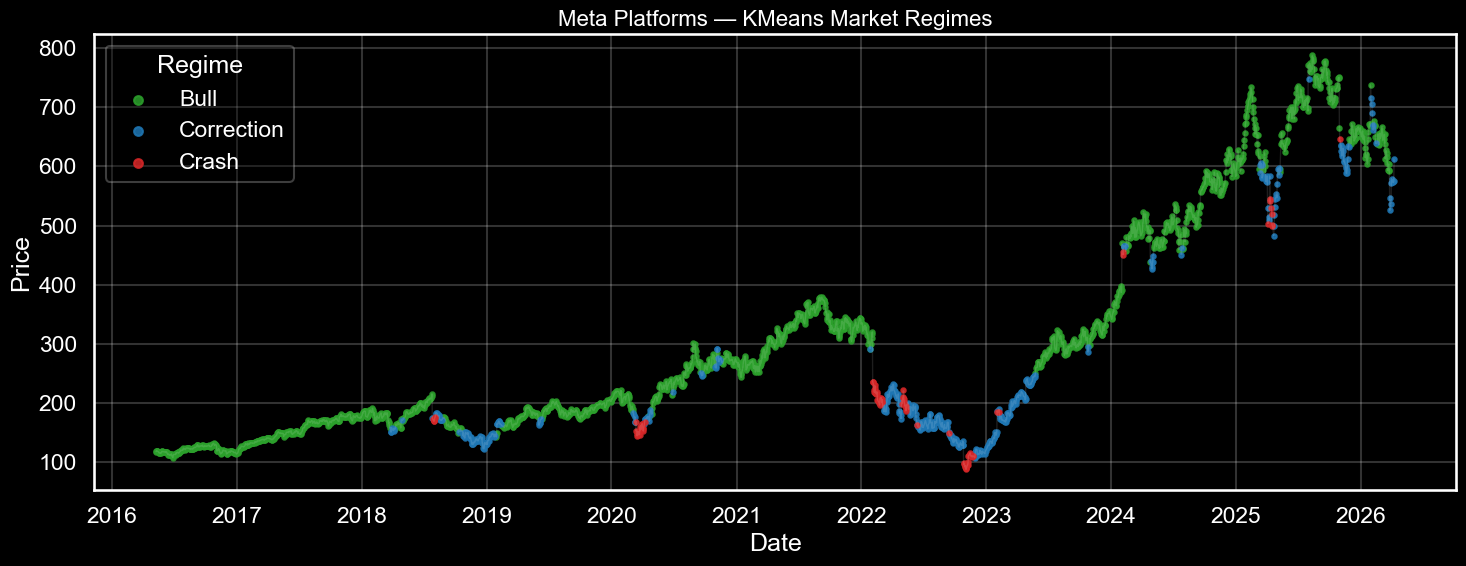

In [10]:
fig, ax = plt.subplots(figsize=(15, 6))

for label in REGIME_ORDER:
    sub = data[data['Regime_Label'] == label]
    ax.scatter(sub.index, sub['Close'],
               color=COLOR_MAP[label], label=label, s=10, alpha=0.85)

ax.plot(data.index, data['Close'], color='white', alpha=0.12, linewidth=1)
ax.set_title(f'{NAME} — KMeans Market Regimes', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Regime', framealpha=0.3, markerscale=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## 10 · Regime Distribution

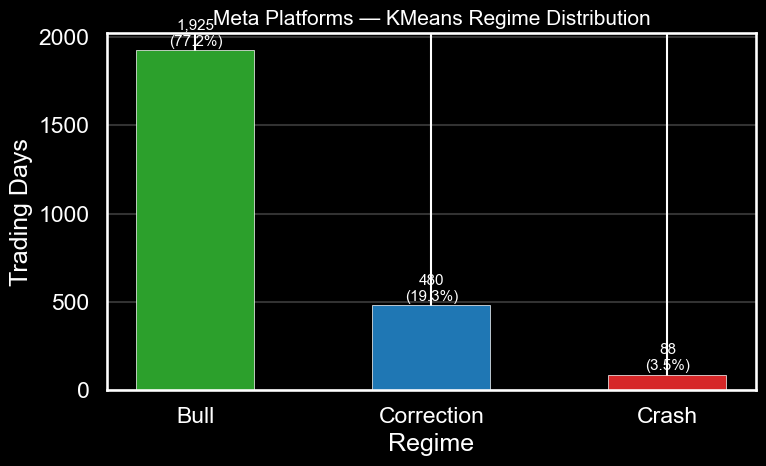

In [11]:
counts = data['Regime_Label'].value_counts().reindex(REGIME_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=[COLOR_MAP[l] for l in counts.index],
              edgecolor='white', linewidth=0.5, width=0.5)

for bar, count in zip(bars, counts.values):
    pct = count / len(data) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title(f'{NAME} — KMeans Regime Distribution', fontsize=15)
ax.set_xlabel('Regime')
ax.set_ylabel('Trading Days')
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

---
## 11 · Return Distributions Per Regime

Shows how return profiles differ across regimes. The width of each distribution reflects volatility — Crash should be visibly wider.

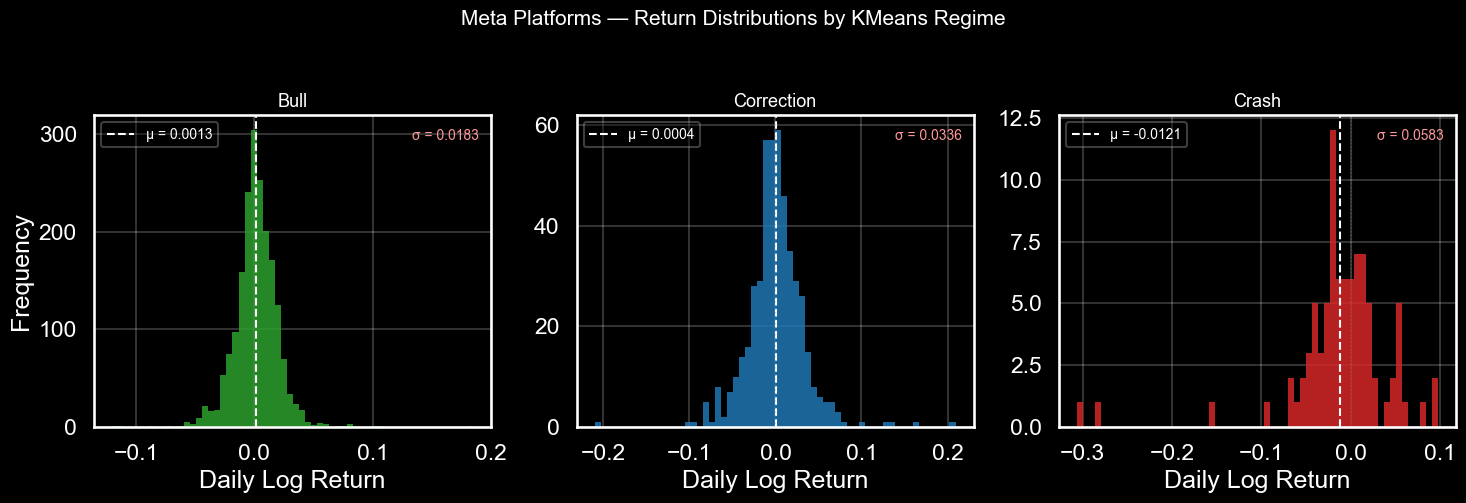

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
colors = ['#2ca02c', '#1f77b4', '#d62728']

for ax, label, color in zip(axes, REGIME_ORDER, colors):
    rets = data[data['Regime_Label'] == label]['Return']
    ax.hist(rets, bins=60, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(rets.mean(), color='white', linestyle='--',
               linewidth=1.5, label=f'μ = {rets.mean():.4f}')
    ax.axvline(0, color='grey', linestyle=':', linewidth=1, alpha=0.4)
    ax.set_title(f'{label}', fontsize=13)
    ax.set_xlabel('Daily Log Return')
    ax.legend(fontsize=10, framealpha=0.3)
    ax.grid(alpha=0.2)
    ax.text(0.97, 0.92, f'σ = {rets.std():.4f}',
            transform=ax.transAxes, ha='right', fontsize=10, color='#FF9999')

axes[0].set_ylabel('Frequency')
plt.suptitle(f'{NAME} — Return Distributions by KMeans Regime', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## 12 · Transition Matrix

The transition matrix shows the probability of moving from one regime to another on the next trading day. In KMeans, this is computed **empirically after classification** — it is not part of the model.

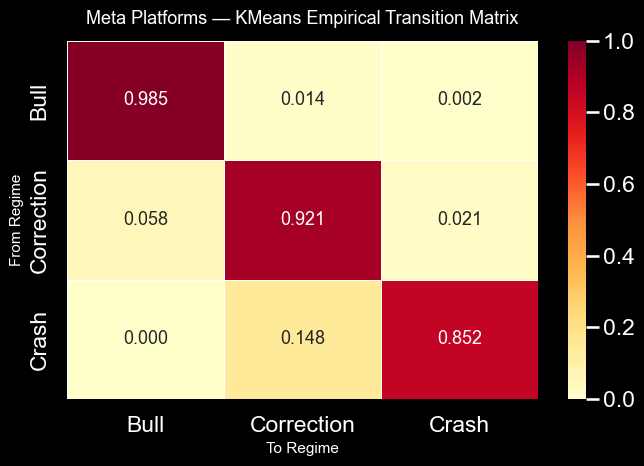

Transition Matrix:
Regime_Label    Bull  Correction   Crash
Prev_Label                              
Bull          0.9849      0.0135  0.0016
Correction    0.0585      0.9207  0.0209
Crash         0.0000      0.1477  0.8523

Note: This matrix is computed post-hoc — KMeans does not model transitions.
Diagonal = regime persistence probability


In [13]:
data['Prev_Label'] = data['Regime_Label'].shift(1)
trans_km = pd.crosstab(
    data['Prev_Label'].dropna(),
    data.loc[data['Prev_Label'].notna(), 'Regime_Label'],
    normalize='index'
).reindex(index=REGIME_ORDER, columns=REGIME_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(trans_km, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 13})
ax.set_title(f'{NAME} — KMeans Empirical Transition Matrix', fontsize=13, pad=12)
ax.set_xlabel('To Regime',   fontsize=11)
ax.set_ylabel('From Regime', fontsize=11)
plt.tight_layout()
plt.show()

print('Transition Matrix:')
print(trans_km.round(4))
print()
print('Note: This matrix is computed post-hoc — KMeans does not model transitions.')
print('Diagonal = regime persistence probability')

---
## 13 · Regime Duration Analysis

In [14]:
data['Regime_Change'] = (data['Regime_Label'] != data['Regime_Label'].shift()).cumsum()

durations = (data.groupby(['Regime_Label', 'Regime_Change'])
                 .size()
                 .groupby(level=0)
                 .agg(['mean','median','max','count'])
                 .rename(columns={'mean':'Avg Days','median':'Median',
                                  'max':'Max Days','count':'Episodes'})
                 .reindex(REGIME_ORDER))

# Theoretical duration from empirical persistence probability
durations['Expected 1/(1−p)'] = [
    round(1 / (1 - trans_km.loc[lbl, lbl]), 1)
    for lbl in durations.index
]

print(f'Regime Duration Analysis — {NAME}')
print('=' * 60)
print(durations.round(1).to_string())
print()
print('Expected 1/(1−p): theoretical mean duration derived from')
print('persistence probability. Should closely match Avg Days.')

Regime Duration Analysis — Meta Platforms
              Avg Days  Median  Max Days  Episodes  Expected 1/(1−p)
Regime_Label                                                        
Bull              66.4    42.0       474        29              66.4
Correction        12.3     5.0        75        39              12.6
Crash              6.8     2.0        20        13               6.8

Expected 1/(1−p): theoretical mean duration derived from
persistence probability. Should closely match Avg Days.


---
## 14 · Price vs Rolling VaR (99%)

Parametric Gaussian VaR. Note: this underestimates true tail risk in crash regimes due to fat-tailed return distributions.

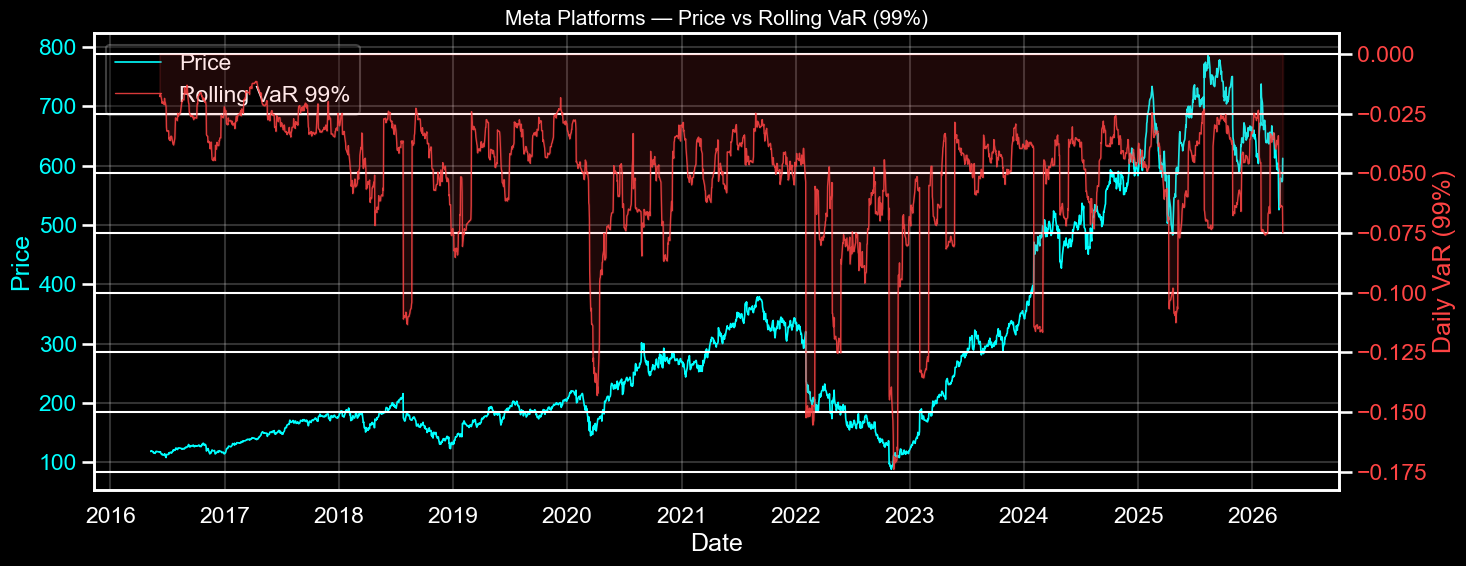

In [15]:
data['VaR_99'] = -(data['Return'].rolling(20).mean() + 2.33 * data['Volatility'])

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(data.index, data['Close'], color='#00FFFF',
         linewidth=1.2, label='Price')
ax1.set_ylabel('Price', color='#00FFFF')
ax1.tick_params(axis='y', labelcolor='#00FFFF')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(data.index, data['VaR_99'], color='#FF4444',
         linewidth=1, alpha=0.85, label='Rolling VaR 99%')
ax2.fill_between(data.index, data['VaR_99'], alpha=0.12, color='#FF4444')
ax2.set_ylabel('Daily VaR (99%)', color='#FF4444')
ax2.tick_params(axis='y', labelcolor='#FF4444')

lines  = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', framealpha=0.3)

ax1.set_title(f'{NAME} — Price vs Rolling VaR (99%)', fontsize=15)
ax1.set_xlabel('Date')
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.show()

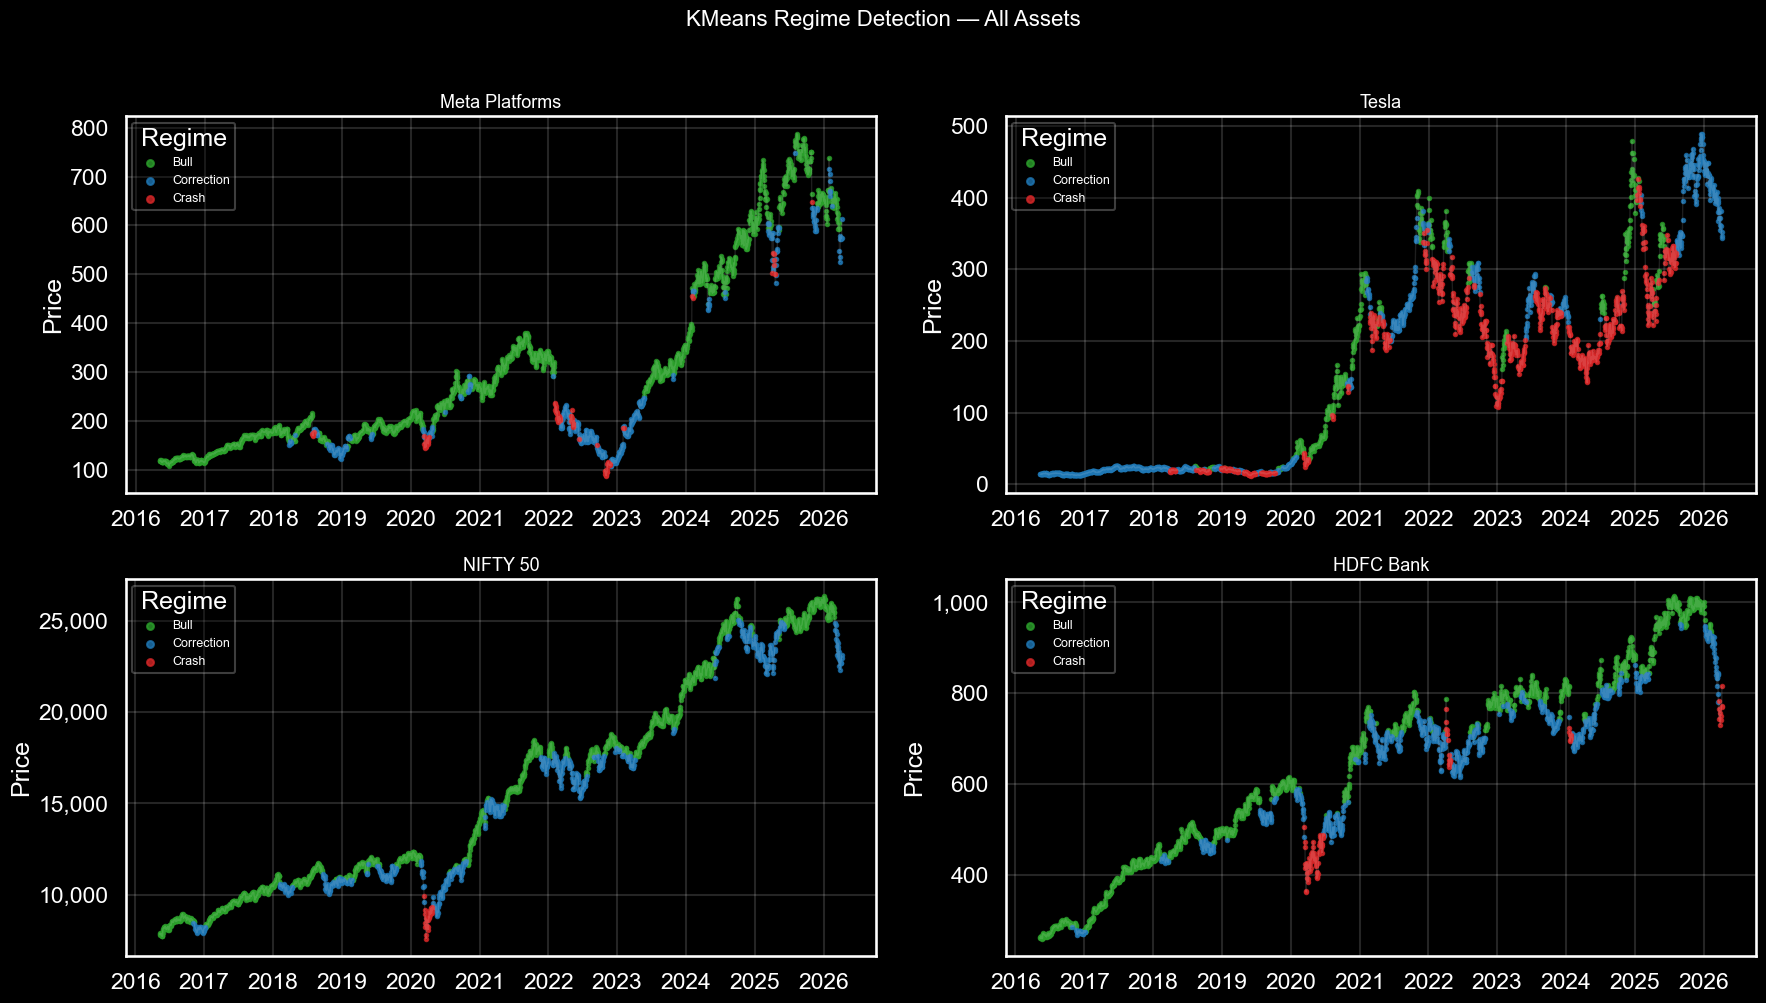

In [16]:
# ── Cross-Asset Regime Overview ──────────────────────────────────────────────
import yfinance as yf

ASSETS = {
    'META'    : 'Meta Platforms',
    'TSLA'    : 'Tesla',
    '^NSEI'   : 'NIFTY 50',
    'HDFCBANK.NS': 'HDFC Bank'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (symbol, name) in zip(axes, ASSETS.items()):

    # Download & features
    raw = yf.download(symbol, period='10y', auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        col = 'Close' if 'Close' in raw.columns.get_level_values(0) else raw.columns.get_level_values(0)[0]
        px  = raw.xs(col, level=0, axis=1).squeeze().dropna()
    else:
        px = raw['Close'].dropna() if 'Close' in raw.columns else raw.iloc[:,0].dropna()

    d = px.to_frame(name='Close')
    d['Return']     = np.log(d['Close'] / d['Close'].shift(1))
    d['Volatility'] = d['Return'].rolling(20).std()
    d['Momentum']   = d['Close'] / d['Close'].shift(20) - 1
    d['Rolling_Max']= d['Close'].cummax()
    d['Drawdown']   = (d['Close'] - d['Rolling_Max']) / d['Rolling_Max']

    rpct    = d['Return'].dropna() * 100
    gfit    = arch_model(rpct, vol='Garch', p=1, q=1).fit(disp='off')
    d.loc[rpct.index, 'GARCH_vol'] = gfit.conditional_volatility / 100
    d = d.dropna().copy()

    # KMeans
    feats  = ['Volatility', 'Momentum', 'Drawdown', 'GARCH_vol']
    Xs     = StandardScaler().fit_transform(d[feats])
    km     = KMeans(n_clusters=3, random_state=42, n_init=10)
    d['Regime'] = km.fit_predict(Xs).astype(int)

    # Auto-label
    st  = d.groupby('Regime').agg(mean_return=('Return','mean'), mean_vol=('Volatility','mean'))
    st.index = st.index.astype(int)
    b   = int(st['mean_return'].idxmax())
    cr  = int(st.drop(index=b)['mean_vol'].idxmax())
    co  = int([r for r in st.index if r not in [b, cr]][0])
    lbl = {b:'Bull', cr:'Crash', co:'Correction'}
    d['Regime_Label'] = d['Regime'].map(lbl)

    # Plot
    for label in ['Bull','Correction','Crash']:
        sub = d[d['Regime_Label'] == label]
        ax.scatter(sub.index, sub['Close'],
                   color=COLOR_MAP[label], label=label, s=6, alpha=0.8)

    ax.plot(d.index, d['Close'], color='white', alpha=0.12, linewidth=1)
    ax.set_title(name, fontsize=13)
    ax.set_ylabel('Price')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(title='Regime', fontsize=9, markerscale=2, framealpha=0.3)
    ax.grid(alpha=0.15)

plt.suptitle('KMeans Regime Detection — All Assets', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 15 · Key Findings Summary

In [17]:
bull_row  = summary[summary['Regime_Label'] == 'Bull'].iloc[0]
corr_row  = summary[summary['Regime_Label'] == 'Correction'].iloc[0]
crash_row = summary[summary['Regime_Label'] == 'Crash'].iloc[0]

print(f'{'═'*58}')
print(f'  KMEANS REGIME SUMMARY — {NAME}')
print(f'{'═'*58}')
print(f'  Model      : K-Means | k={N_CLUSTERS} | Seed={SEED}')
print(f'  Date range : {data.index[0].date()} → {data.index[-1].date()}')
print()
print(f'  REGIME STATISTICS')
print(f'    {"Regime":<12} {"Return":>9} {"Volatility":>12} {"Drawdown":>10} {"VaR 99%":>9} {"Avg Days":>10}')
print(f'    {"-"*58}')
for row in [bull_row, corr_row, crash_row]:
    print(f'    {row.Regime_Label:<12} {row.Return:>9.3%} {row.Volatility:>12.3%} {row.Drawdown:>10.2%} {row.VaR_99:>9.3%} {row.Avg_Duration:>10.1f}')
print()
print(f'  REGIME PERSISTENCE (empirical)')
for lbl in REGIME_ORDER:
    p = trans_km.loc[lbl, lbl]
    print(f'    {lbl:<12}: {p:.1%} daily persistence → ~{1/(1-p):.1f} day expected duration')
print()
print(f'  LIMITATION')
print(f'    Transition matrix is post-hoc — not a model parameter.')
print(f'    KMeans has no time memory: every day classified in isolation.')
print(f'{'═'*58}')

══════════════════════════════════════════════════════════
  KMEANS REGIME SUMMARY — Meta Platforms
══════════════════════════════════════════════════════════
  Model      : K-Means | k=3 | Seed=42
  Date range : 2016-05-09 → 2026-04-08

  REGIME STATISTICS
    Regime          Return   Volatility   Drawdown   VaR 99%   Avg Days
    ----------------------------------------------------------
    Bull            0.131%       1.704%     -8.26%   -4.406%       66.4
    Correction      0.038%       3.185%    -41.28%   -7.855%       12.3
    Crash          -1.206%       6.087%    -44.30%  -12.370%        6.8

  REGIME PERSISTENCE (empirical)
    Bull        : 98.5% daily persistence → ~66.4 day expected duration
    Correction  : 92.1% daily persistence → ~12.6 day expected duration
    Crash       : 85.2% daily persistence → ~6.8 day expected duration

  LIMITATION
    Transition matrix is post-hoc — not a model parameter.
    KMeans has no time memory: every day classified in isolation.
═══

---

### What This Model Tells Us

K-Means successfully identifies three statistically distinct market states from the feature space. The regime-colored price chart, transition matrix, and duration statistics together tell a coherent story of how this asset cycles through bull, correction, and crash phases.

**Core limitation:** Because K-Means treats every day as independent, it cannot model the *sequential* nature of regimes — the fact that being in a crash today makes it more likely to be in a crash tomorrow. That persistence is a fundamental property of financial markets, and it motivates the Hidden Markov Model in the companion notebook.

---
*See `HMM_Regime_Detection.ipynb` for the time-aware probabilistic model.*